# Train Conditional VAE

Dataset: `data/data.txt`. Saves the best checkpoint by validation joint compliance.

**Reproducibility:** `seed=42` set in every entry point.


In [1]:
# Colab bootstrap: clone the repo if we're on Colab, set the cwd.
import os, sys, subprocess, pathlib
REPO_URL = 'https://github.com/a7mdka7la/GAN-AI-project.git'
REPO_DIR = pathlib.Path("/content/Assignment2")
if "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    if not REPO_DIR.exists():
        # If the user has already uploaded the zip, prefer that.
        zip_path = pathlib.Path("/content/Assignment2.zip")
        if zip_path.exists():
            subprocess.run(["unzip", "-q", str(zip_path), "-d", "/content"], check=True)
        else:
            subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(str(REPO_DIR))
else:
    # Local: cd to the repo (this notebooks/ dir's parent).
    os.chdir(str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()))
sys.path.insert(0, os.getcwd())
print("cwd =", os.getcwd())
print("files:", os.listdir(".")[:10])


cwd = /content/Assignment2
files: ['.gitignore', '.git', 'README.md', 'environment.yml', 'notebooks', 'model', 'PLAN.md', 'data', 'tests', 'report']


## Train

In [2]:
# Train. epochs/batch_size can be raised if you have Colab time budget.
from model.cvae.train import train

best_path = train(
    data_path="data/data.txt",
    out_dir="runs/cvae",
    epochs=60,
    batch_size=1024,
    device="cuda",
    seed=42,
)
print("Best checkpoint:", best_path)


[cvae] ep 00 nll=1.8895 kl=215.7331 beta=0.000 val_joint=0.1523 *
[cvae] ep 01 nll=0.1132 kl=28.4349 beta=0.020 val_joint=0.1458
[cvae] ep 02 nll=0.0718 kl=12.6750 beta=0.040 val_joint=0.1506
[cvae] ep 03 nll=0.0776 kl=10.0829 beta=0.060 val_joint=0.1484
[cvae] ep 04 nll=0.0892 kl=8.8390 beta=0.080 val_joint=0.1360
[cvae] ep 05 nll=0.1055 kl=8.2296 beta=0.100 val_joint=0.1509
[cvae] ep 06 nll=0.1009 kl=8.0361 beta=0.100 val_joint=0.1340
[cvae] ep 07 nll=0.0957 kl=7.8693 beta=0.100 val_joint=0.1445
[cvae] ep 08 nll=0.0931 kl=7.7694 beta=0.100 val_joint=0.1448
[cvae] ep 09 nll=0.0899 kl=7.6984 beta=0.100 val_joint=0.1426
[cvae] ep 10 nll=0.0874 kl=7.6516 beta=0.100 val_joint=0.1499
[cvae] ep 11 nll=0.0842 kl=7.5827 beta=0.100 val_joint=0.1396
[cvae] ep 12 nll=0.0835 kl=7.5494 beta=0.100 val_joint=0.1392
[cvae] ep 13 nll=0.0812 kl=7.5082 beta=0.100 val_joint=0.1440
[cvae] ep 14 nll=0.0811 kl=7.4939 beta=0.100 val_joint=0.1418
[cvae] ep 15 nll=0.0805 kl=7.4671 beta=0.100 val_joint=0.1467
[

## Promote checkpoint

In [3]:
# Promote the best checkpoint to the location predict.py expects.
import shutil, pathlib
src = pathlib.Path("runs/cvae/cvae_best.pt")
dst = pathlib.Path("model/weights/cvae.pt")
dst.parent.mkdir(parents=True, exist_ok=True)
shutil.copy(src, dst)
print(f"Copied {src} -> {dst}")


Copied runs/cvae/cvae_best.pt -> model/weights/cvae.pt


## Quick smoke-evaluation on example_input.txt

In [4]:
# Quick smoke-eval on example_input.txt
import subprocess, sys
out = subprocess.run(
    [sys.executable, "-m", "model.evaluate",
     "--input", "data/example_input.txt", "--model", "cvae"],
    capture_output=True, text=True,
)
print(out.stdout)
if out.returncode != 0:
    print("STDERR:", out.stderr, file=sys.stderr)


n                       : 1465
validity (in-range, legal): 1.0000
acc_dow  (day-of-week)  : 0.1461
acc_month               : 1.0000
acc_leap                : 1.0000
acc_decade              : 1.0000
acc_joint (all 4 + valid): 0.1461
diversity entropy (mean): 2.2598



## Training/validation curves

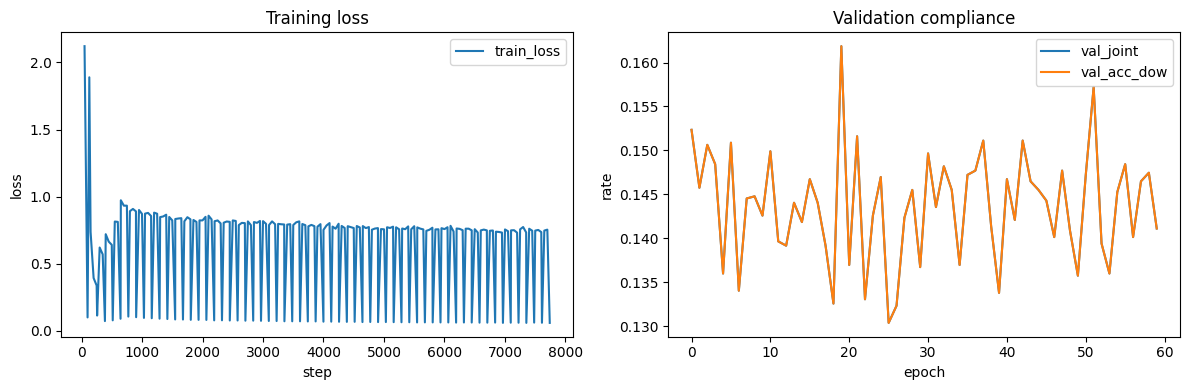

In [5]:
# Plot training loss + val joint compliance.
import json, matplotlib.pyplot as plt, pathlib
rows = [json.loads(l) for l in pathlib.Path("runs/cvae/log.jsonl").read_text().splitlines() if l.strip()]
ep_rows = [r for r in rows if r.get("val_joint_compliance") is not None]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([r["step"] for r in rows], [r["train_loss"] for r in rows], label="train_loss")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss"); ax[0].set_title("Training loss"); ax[0].legend()
ax[1].plot([r["epoch"] for r in ep_rows], [r["val_joint_compliance"] for r in ep_rows], label="val_joint")
ax[1].plot([r["epoch"] for r in ep_rows], [r["val_acc_dow"] for r in ep_rows], label="val_acc_dow")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("rate"); ax[1].set_title("Validation compliance"); ax[1].legend()
plt.tight_layout(); plt.show()
